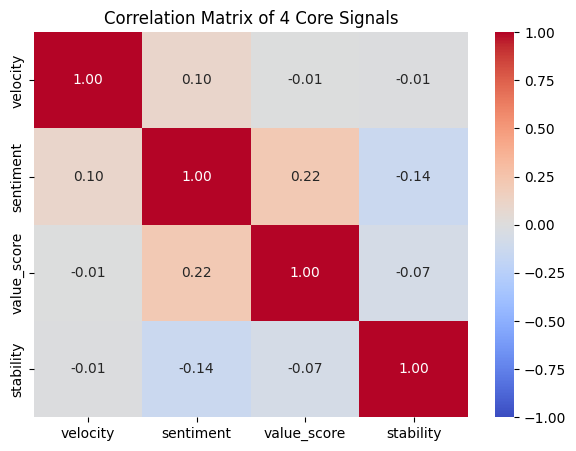

========== 다중공선성 검증 결과 (VIF) ==========


,Signal_Indicator,VIF_Score
1,sentiment,1.077041
2,value_score,1.052299
3,stability,1.020138
0,velocity,1.010168


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. 파일 로드 (알려주신 절대/상대 경로 그대로 적용)
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

# 날짜 형식 변환 및 출시 후 90일 필터링 준비
reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

# 리뷰 데이터에 게임 출시일 병합
reviews_merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'price', 'performance_grade']], on='appid')

# 출시 후 90일 이내에 작성된 리뷰만 필터링 (초기 90일 골든타임)
reviews_merged['days_since_release'] = (reviews_merged['created_date'] - reviews_merged['release_date']).dt.days
early_reviews = reviews_merged[(reviews_merged['days_since_release'] >= 0) & (reviews_merged['days_since_release'] <= 90)].copy()

# 2. 오리지널 6대 시그널 추출 함수
def extract_original_signals(group):
    # 1) Velocity (화제성): 초기 90일 리뷰 수
    velocity = len(group)
    
    # 2) Sentiment (초기 민심): 긍정 리뷰 비율
    sentiment = group['voted_up'].mean()
    
    # 3) Loyalty (몰입 깊이): 리뷰 작성 시점의 평균 플레이타임
    loyalty = group['playtime_at_review_hours'].mean()
    
    # 4) Influence (리뷰 전파력): '도움돼요' 가중치 총합
    influence = group['weighted_vote_score'].sum()
    
    # 5) Stability (민심 안정도): 90일간 (주차별) 긍정률의 표준편차
    group['week_since_release'] = group['days_since_release'] // 7
    weekly_sentiment = group.groupby('week_since_release')['voted_up'].mean()
    stability = weekly_sentiment.std() if len(weekly_sentiment) > 1 else 0
    
    return pd.Series({
        'velocity': velocity,
        'sentiment': sentiment,
        'loyalty': loyalty,
        'influence': influence,
        'stability': stability
    })

print("오리지널 6대 시그널을 추출하는 중입니다...")
signals_df = early_reviews.groupby('appid').apply(extract_original_signals).reset_index()

# 6) Value Score (가성비): Loyalty(평균 플레이타임) / 가격
final_df = pd.merge(signals_df, graded_df[['appid', 'price']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# 결측치 처리
signal_cols = ['velocity', 'sentiment', 'loyalty', 'influence', 'stability', 'value_score']
X = final_df[signal_cols].fillna(0)

# 3. 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Correlation Heatmap of Original 6 Signals", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. VIF (다중공선성) 계산
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled_df.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_scaled_df.values, i) 
                          for i in range(len(X_scaled_df.columns))]

vif_data = vif_data.sort_values(by="VIF_Score", ascending=False).reset_index(drop=True)

print("\n=== 오리지널 6대 시그널 다중공선성 검증 (VIF Scores) ===")
print("기준: VIF > 10 이면 다중공선성 위험.")
print("-" * 50)
print(vif_data)

초기 데이터를 가공하여 시그널을 추출하는 중입니다...

=== 오리지널 6대 시그널 VIF ===
    Feature    VIF_Score
  influence 22105.211397
   velocity 22093.890589
    loyalty     5.030670
value_score     4.917958
  stability     1.256181
  sentiment     1.195260


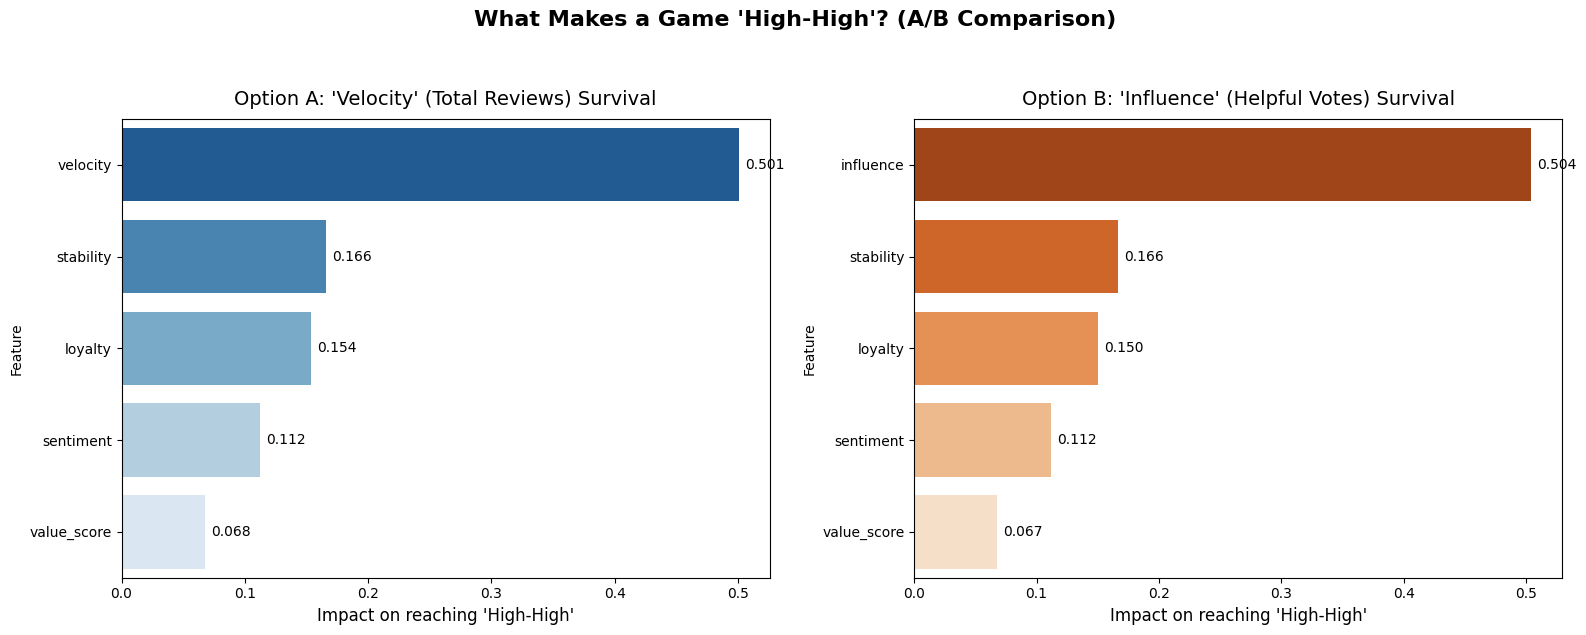

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 데이터 로드 및 초기 필터링
# ==========================================
reviews_df = pd.read_csv('../../../../data/preprocessed/steam_indie_reviews.csv')
graded_df = pd.read_csv('../../../../data/preprocessed/steam_indie_games_graded.csv')

reviews_df['created_date'] = pd.to_datetime(reviews_df['created_date'])
graded_df['release_date'] = pd.to_datetime(graded_df['release_date'])

reviews_merged = pd.merge(reviews_df, graded_df[['appid', 'release_date', 'price', 'performance_grade']], on='appid')
reviews_merged['days_since_release'] = (reviews_merged['created_date'] - reviews_merged['release_date']).dt.days
early_reviews = reviews_merged[(reviews_merged['days_since_release'] >= 0) & (reviews_merged['days_since_release'] <= 90)].copy()

# ==========================================
# 2. 오리지널 6대 시그널 추출
# ==========================================
def extract_original_signals(group):
    velocity = len(group)
    sentiment = group['voted_up'].mean()
    loyalty = group['playtime_at_review_hours'].mean()
    influence = group['weighted_vote_score'].sum()
    
    group['week_since_release'] = group['days_since_release'] // 7
    weekly_sentiment = group.groupby('week_since_release')['voted_up'].mean()
    stability = weekly_sentiment.std() if len(weekly_sentiment) > 1 else 0
    
    return pd.Series({
        'velocity': velocity,
        'sentiment': sentiment,
        'loyalty': loyalty,
        'influence': influence,
        'stability': stability
    })

print("초기 데이터를 가공하여 시그널을 추출하는 중입니다...")
signals_df = early_reviews.groupby('appid').apply(extract_original_signals).reset_index()

# 💡 [수정됨] 다음 분석을 위해 'performance_grade'를 반드시 함께 병합해야 합니다!
final_df = pd.merge(signals_df, graded_df[['appid', 'price', 'performance_grade']], on='appid')
final_df['value_score'] = final_df['loyalty'] / (final_df['price'] + 1)

# ==========================================
# 3. VIF 및 상관관계 검증 (결과 출력만)
# ==========================================
signal_cols = ['velocity', 'sentiment', 'loyalty', 'influence', 'stability', 'value_score']
X_full = final_df[signal_cols].fillna(0)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_full), columns=signal_cols)
vif_data = pd.DataFrame({
    "Feature": X_scaled.columns,
    "VIF_Score": [variance_inflation_factor(X_scaled.values, i) for i in range(len(X_scaled.columns))]
}).sort_values(by="VIF_Score", ascending=False)

print("\n=== 오리지널 6대 시그널 VIF ===")
print(vif_data.to_string(index=False))

# ==========================================
# 4. 머신러닝 (Random Forest) 비교 분석
# ==========================================
# 타겟 변수 세팅 ('high_high' 등급이면 1, 아니면 0)
y = (final_df['performance_grade'] == 'high_high').astype(int)

# 🚨 옵션 A: 'velocity(화제성/리뷰 수)'를 남기고 influence 제거
features_A = ['velocity', 'sentiment', 'loyalty', 'stability', 'value_score']
X_A = final_df[features_A].fillna(0)
X_train_A, X_test_A, y_train, y_test = train_test_split(X_A, y, test_size=0.2, random_state=42, stratify=y)

rf_A = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_A.fit(X_train_A, y_train)
imp_A = pd.DataFrame({'Feature': features_A, 'Importance': rf_A.feature_importances_}).sort_values(by='Importance', ascending=False)

# 🚨 옵션 B: 'influence(리뷰 전파력)'를 남기고 velocity 제거
features_B = ['influence', 'sentiment', 'loyalty', 'stability', 'value_score']
X_B = final_df[features_B].fillna(0)
X_train_B, X_test_B, _, _ = train_test_split(X_B, y, test_size=0.2, random_state=42, stratify=y)

rf_B = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_B.fit(X_train_B, y_train)
imp_B = pd.DataFrame({'Feature': features_B, 'Importance': rf_B.feature_importances_}).sort_values(by='Importance', ascending=False)

# ==========================================
# 5. 결과 시각화 (두 옵션 나란히 비교)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 옵션 A 그래프
sns.barplot(x='Importance', y='Feature', data=imp_A, ax=axes[0], palette='Blues_r')
axes[0].set_title("Option A: 'Velocity' (Total Reviews) Survival", fontsize=14, pad=10)
axes[0].set_xlabel("Impact on reaching 'High-High'", fontsize=12)
for index, value in enumerate(imp_A['Importance']):
    axes[0].text(value + 0.005, index, f"{value:.3f}", va='center')

# 옵션 B 그래프
sns.barplot(x='Importance', y='Feature', data=imp_B, ax=axes[1], palette='Oranges_r')
axes[1].set_title("Option B: 'Influence' (Helpful Votes) Survival", fontsize=14, pad=10)
axes[1].set_xlabel("Impact on reaching 'High-High'", fontsize=12)
for index, value in enumerate(imp_B['Importance']):
    axes[1].text(value + 0.005, index, f"{value:.3f}", va='center')

plt.suptitle("What Makes a Game 'High-High'? (A/B Comparison)", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()